# 01 — EDA y formulación de hipótesis de señal

1. Objetivo y metodología
2. H1 — Momentum vs. Mean Reversion
3. H2 — ¿Cuándo aparece la información?
4. H3 — Volatilidad y régimen direccional
5. H4 — Estado cross-sectional del mercado
6. H5 — Comportamiento relativo al mercado
7. Síntesis de hipótesis y paso a validación

# 01 — EDA y Formulación de Hipótesis de Señal

## 1. Objetivo

La auditoría inicial mostró que el problema consiste en predecir el régimen
direccional de las últimas dos horas de trading a partir de la trayectoria
observada entre las 09:30 y las 14:00.

El objetivo de esta notebook es investigar si dicha trayectoria contiene
estructura estadística potencialmente informativa sobre `reod` y formular
hipótesis concretas que posteriormente puedan evaluarse fuera de muestra.

A diferencia de la auditoría realizada en `00`, esta etapa comienza a estudiar
la relación entre las variables disponibles y el target.

Sin embargo, el propósito todavía no es optimizar un modelo predictivo.

La metodología será:

$$
\text{intuición económica}
\rightarrow
\text{hipótesis}
\rightarrow
\text{evidencia exploratoria}
\rightarrow
\text{hipótesis candidata}
$$

Las relaciones encontradas durante esta notebook se considerarán evidencia
exploratoria y no evidencia fuera de muestra.

Cualquier señal candidata deberá ser evaluada posteriormente mediante un
framework de validación que respete la separación entre días y equities.

## 2. H1 — Momentum vs. Mean Reversion

La primera hipótesis investiga si la dirección acumulada observada antes de
las 14:00 contiene información sobre la dirección posterior.

Existen dos mecanismos potenciales y opuestos.

### Hipótesis de momentum

Si existe persistencia intradía, movimientos positivos durante la ventana
observada deberían estar asociados con una mayor probabilidad de observar
`reod = +1`, mientras que movimientos negativos deberían asociarse con
`reod = -1`.

$$
R^{obs}_{i,d}>0
\Rightarrow
P(Y_{i,d}=+1)\uparrow
$$

### Hipótesis de mean reversion

Alternativamente, si los movimientos intradía tienden a corregirse, retornos
acumulados positivos podrían incrementar la probabilidad de una dirección
posterior negativa, y viceversa.

$$
R^{obs}_{i,d}>0
\Rightarrow
P(Y_{i,d}=-1)\uparrow
$$

El objetivo inicial será determinar cuál de estos dos comportamientos, si
alguno, aparece en los datos.

No sumamos los bps directamente como si fueran el retorno exacto acumulado. 
Tenemos el retorno en puntos base (bps):

$$r_t = 10^4 \left( \frac{P_{t+1}}{P_t} - 1 \right)$$

Entonces podemos reconstruir el retorno compuesto tradicional:

$$R_{0:T} = \prod_{t=0}^{T} \left(1 + \frac{r_t}{10^4}\right) - 1$$

Y volverlo a expresar en puntos base (bps):

$$R_{0:T}^{\text{bps}} = 10^4 \left[ \prod_{t=0}^{T} \left(1 + \frac{r_t}{10^4}\right) - 1 \right]$$

Para movimientos pequeños, $\sum_{t} r_t$ será una aproximación muy buena, pero tenemos 53 observaciones y podemos calcularlo correctamente.


In [8]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
input_train = pd.read_csv('C:../data/input_training.csv ')
input_test = pd.read_csv('C:../data/input_test.csv')
output_train = pd.read_csv('C:../data/output_training_gmEd6Zt.csv')
output_test = pd.read_csv('C:../data/output_test_random.csv')

In [4]:
# para la primera exploración podemos calcular el retorno acumulado solo para trayectorias completas
train = input_train.merge(output_train,on="ID",how="inner",validate="one_to_one")
return_cols = [f"r{i}" for i in range(53)]
analysis = train.copy()
analysis["complete_path"] = (analysis[return_cols].notna().all(axis=1))
complete = analysis.loc[analysis["complete_path"]].copy()
complete["cum_return_bps"] = ((1 + complete[return_cols] / 10_000).prod(axis=1) - 1) * 10_000
print(f"Observaciones totales: {len(analysis):,}")
print(f"Trayectorias completas: {len(complete):,}")
print(f"Porcentaje conservado: "f"{len(complete) / len(analysis):.2%}")

Observaciones totales: 843,299
Trayectorias completas: 600,936
Porcentaje conservado: 71.26%


In [6]:
# dividir el retorno observado en quintiles:
complete["momentum_quintile"] = pd.qcut(complete["cum_return_bps"],q=5,labels=["Q1 - Muy negativo","Q2","Q3","Q4","Q5 - Muy positivo"])
momentum_target = (complete.groupby("momentum_quintile", observed=True)["reod"].value_counts(normalize=True).unstack(fill_value=0))
momentum_target.columns = [f"class_{c}" for c in momentum_target.columns]
momentum_target

,class_-1,class_0,class_1
momentum_quintile,,,
Q1 - Muy negativo,0.365536,0.270601,0.363863
Q2,0.313944,0.380748,0.305308
Q3,0.283383,0.446837,0.269780
Q4,0.309618,0.401216,0.289166
Q5 - Muy positivo,0.363176,0.295115,0.341709


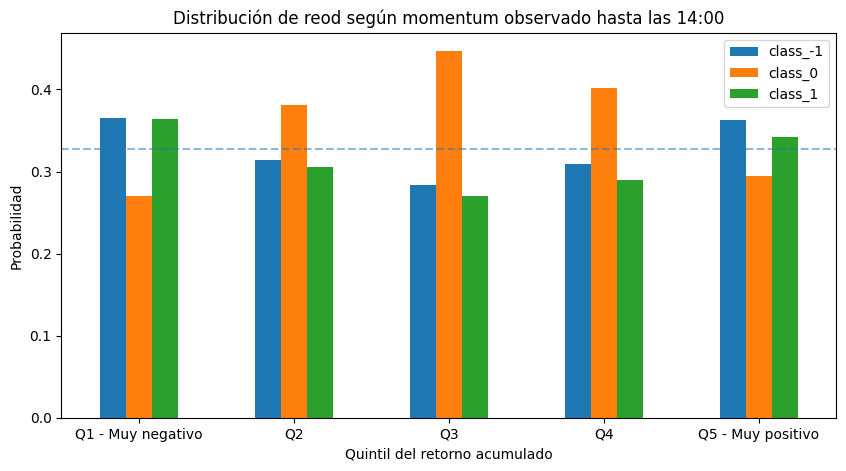

In [9]:
momentum_target.plot(kind="bar",figsize=(10, 5))
plt.axhline((complete["reod"] == -1).mean(),linestyle="--",alpha=0.5)
plt.title("Distribución de reod según momentum observado hasta las 14:00")
plt.xlabel("Quintil del retorno acumulado")
plt.ylabel("Probabilidad")
plt.xticks(rotation=0)
plt.show()